# **Telco Customer Churn project**

The project uses the [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download) (~7043 customers, 21 features)

It includes:

* Customer demographics
* Service usage (internet, phone, etc.)
* Billing info (monthly charges, total charges)
* Target: Churn (Yes/No)

### **STEP 0 — Setup Environment**

In [2]:
# Install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

### **STEP 1 — Load Dataset**

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **STEP 2 — Data Cleaning**

**2.1 Remove unnecessary column**

In [4]:
df.drop("customerID", axis=1, inplace=True)

**2.2 Fix TotalCharges**

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_15599/551351825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


**2.3 Encode target**

In [6]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

### **STEP 3 — Encode Categorical Variables**

In [7]:
categorical_cols = df.select_dtypes(include=["object"]).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

### **STEP 4 — Train-Test Split**

In [8]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **STEP 5 — Feature Scaling**

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **STEP 6 — Train MULTIPLE Models**

**6.1 Logistic Regression**

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**6.2 K-Nearest Neighbors**

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

**6.3 Decision Tree**

In [12]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

**6.4 Random Forest**

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**6.5 Support Vector Machine (SVM)**

In [14]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

**6.6 Naive Bayes**

In [15]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

**6.7 Gradient Boosting**

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

**6.8 XGBoost**

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:33:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**6.9 LightGBM**

In [18]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### **STEP 7 — Evaluate ALL Models**

In [19]:
models = {
    "Logistic Regression": (lr, y_pred_lr),
    "KNN": (knn, y_pred_knn),
    "Decision Tree": (dt, y_pred_dt),
    "Random Forest": (rf, y_pred_rf),
    "SVM": (svm, y_pred_svm),
    "Naive Bayes": (nb, y_pred_nb),
    "Gradient Boosting": (gb, y_pred_gb),
    "XGBoost": (xgb, y_pred_xgb),
    "LightGBM": (lgbm, y_pred_lgbm),
}

results = []

for name, (model, y_pred) in models.items():
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    results.append([name, acc, roc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC-AUC"])
print(results_df.sort_values(by="ROC-AUC", ascending=False))

                 Model  Accuracy   ROC-AUC
6    Gradient Boosting  0.798439  0.842132
0  Logistic Regression  0.806955  0.841585
8             LightGBM  0.794890  0.829954
3        Random Forest  0.792051  0.825852
7              XGBoost  0.784954  0.821414
5          Naive Bayes  0.655784  0.809254
4                  SVM  0.792761  0.796035
1                  KNN  0.747339  0.771604
2        Decision Tree  0.740951  0.660957


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### **STEP 8 — Confusion Matrix**

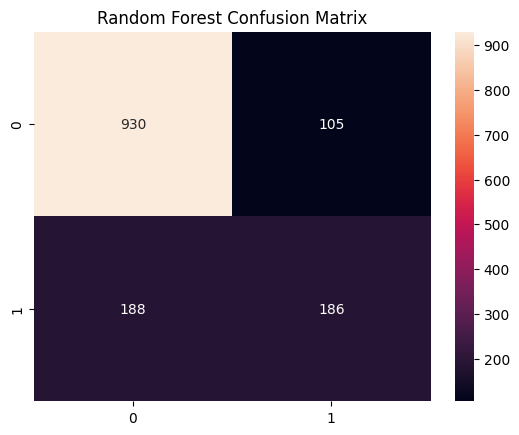

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

### **STEP 9 — Feature Importance**

In [21]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({"Feature": features, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)

print(feat_imp.head(10))

                           Feature  Importance
3                     TotalCharges    0.194123
1                           tenure    0.171364
2                   MonthlyCharges    0.167562
10     InternetService_Fiber optic    0.038864
28  PaymentMethod_Electronic check    0.038285
25               Contract_Two year    0.031477
4                      gender_Male    0.028519
13              OnlineSecurity_Yes    0.027796
26            PaperlessBilling_Yes    0.025725
5                      Partner_Yes    0.023285


### **STEP 10 — Model Comparison Plot**

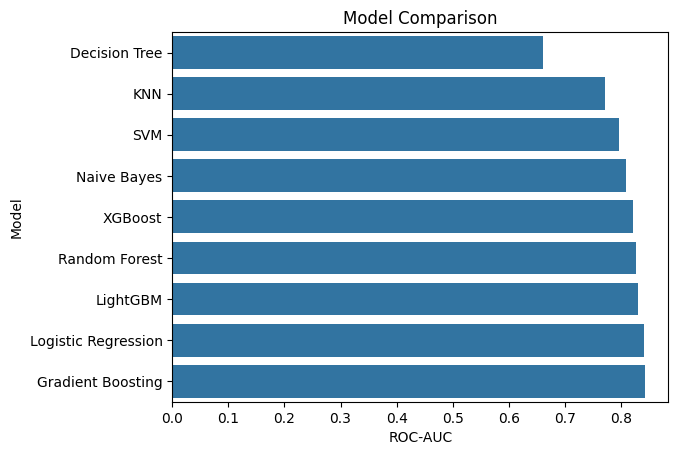

In [22]:
sns.barplot(x="ROC-AUC", y="Model", data=results_df.sort_values(by="ROC-AUC"))
plt.title("Model Comparison")
plt.show()

### **STEP 11 — Save The Best Model**

In [24]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(gb, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save column structure
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns, f)